To perform EDA, parquet files from model_predictions (gold table) were extracted into csv and renamed xgboostv1_predictions.csv

In [1]:
import pandas as pd
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
## files were merged and code was not rerun in order not to overwrite the file. Output of the code cell shown below.



# pred_dir  = Path("/Users/paulineng/MLE/MLEA2/scripts/datamart/gold/model_predictions/xgboostv1.")
# label_dir = Path("/Users/paulineng/MLE/MLEA2/scripts/datamart/gold/label_store")

# pred_files = sorted(pred_dir.glob("*.parquet"))
# if not pred_files:
#     raise FileNotFoundError(f"No prediction .parquet files found under {pred_dir}")
# preds = pd.concat((pd.read_parquet(f) for f in pred_files), ignore_index=True)

# label_dirs = sorted(label_dir.glob("gold_label_store_*.parquet"))
# if not label_dirs:
#     raise FileNotFoundError(f"No label-store .parquet directories found under {label_dir}")
# labels = pd.concat((pd.read_parquet(d) for d in label_dirs), ignore_index=True)

# preds["snapshot_date"]  = pd.to_datetime(preds["snapshot_date"])
# labels["snapshot_date"] = pd.to_datetime(labels["snapshot_date"])
# merged = labels.merge(
#     preds[["Customer_ID", "snapshot_date", "model_predictions"]],
#     on=["Customer_ID", "snapshot_date"],
#     how="left"
# )

# merged["model_name"] = "xgboostv1.json"
# result = merged[["Customer_ID", "snapshot_date", "model_name", "model_predictions"]]
# print("Final row count:", result.shape[0])
# result.to_csv("/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1_predictions.csv", index=False)


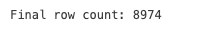

In [3]:
preds_path = "/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1_predictions.csv"
preds_df = pd.read_csv(preds_path)
print(preds_df.shape)
print(preds_df.columns.tolist())
display(preds_df.head(10))

(8974, 4)
['Customer_ID', 'snapshot_date', 'model_name', 'model_predictions']


,Customer_ID,snapshot_date,model_name,model_predictions
0,CUS_0x1037,2023-07-01,xgboostv1.json,0.251601
1,CUS_0x1069,2023-07-01,xgboostv1.json,0.266159
2,CUS_0x114a,2023-07-01,xgboostv1.json,0.338661
3,CUS_0x1184,2023-07-01,xgboostv1.json,0.310813
4,CUS_0x1297,2023-07-01,xgboostv1.json,0.513788
5,CUS_0x12fb,2023-07-01,xgboostv1.json,0.305996
6,CUS_0x1325,2023-07-01,xgboostv1.json,0.402037
7,CUS_0x1341,2023-07-01,xgboostv1.json,0.364747
8,CUS_0x1375,2023-07-01,xgboostv1.json,0.652608
9,CUS_0x13a8,2023-07-01,xgboostv1.json,0.084524


In [4]:
import joblib
from sklearn.pipeline import Pipeline
import xgboost as xgb

# 1) Load your saved object
model_path = "/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1.pkl"
loaded = joblib.load(model_path)

# 2) Drill down to your Pipeline (you already know it lives at root['model'])
pipeline = loaded['model'] if isinstance(loaded, dict) else loaded
if not isinstance(pipeline, Pipeline):
    raise TypeError(f"Expected a sklearn Pipeline at root['model'], got {type(pipeline)}")

# 3) Grab the final XGBClassifier step
clf_name, clf = pipeline.steps[-1]

# 4) Check how many features it expects
if hasattr(clf, "n_features_in_"):
    n_inputs = clf.n_features_in_
else:
    booster = clf.get_booster() if hasattr(clf, "get_booster") else clf
    n_inputs = booster.num_feature()
print(f"Model expects {n_inputs} input features")

# 5) If it’s 19, extract the *transformer* feature names
if n_inputs == 19:
    # a) Make a sub‐pipeline of all but the last (the classifier)
    feature_pipeline = Pipeline(pipeline.steps[:-1])
    
    # b) Pull out names
    if hasattr(feature_pipeline, "get_feature_names_out"):
        names = feature_pipeline.get_feature_names_out()
    else:
        # fallback: scan each step for get_feature_names_out()
        names = None
        for name, step in feature_pipeline.named_steps.items():
            if hasattr(step, "get_feature_names_out"):
                names = step.get_feature_names_out()
                print(f"Pulled names from transformer step: '{name}'")
                break
        if names is None:
            raise AttributeError("No transformer in the pipeline provides get_feature_names_out()")
    
    # 6) Print them
    print("\nInput feature names:")
    for fn in names:
        print(" -", fn)
else:
    print("Not 19 inputs, skipping name extraction.")

Model expects 19 input features

Input feature names:
 - num__Annual_Income
 - num__Num_Bank_Accounts
 - num__Num_Credit_Card
 - num__Interest_Rate
 - num__Num_of_Loan
 - num__Delay_from_due_date
 - num__Num_of_Delayed_Payment
 - num__Num_Credit_Inquiries
 - num__Outstanding_Debt
 - num__Monthly_Balance
 - num__days_overdue_per_late_payment
 - num__Credit_History_Age_num
 - num__debt_to_income_ratio
 - num__monthly_repayment_to_income
 - num__credit_inquiries_per_year
 - num__Student_Loan_count
 - cat__Credit_Mix_Bad
 - cat__Payment_of_Min_Amount_No
 - cat__Payment_of_Min_Amount_Yes


/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.1 when using v

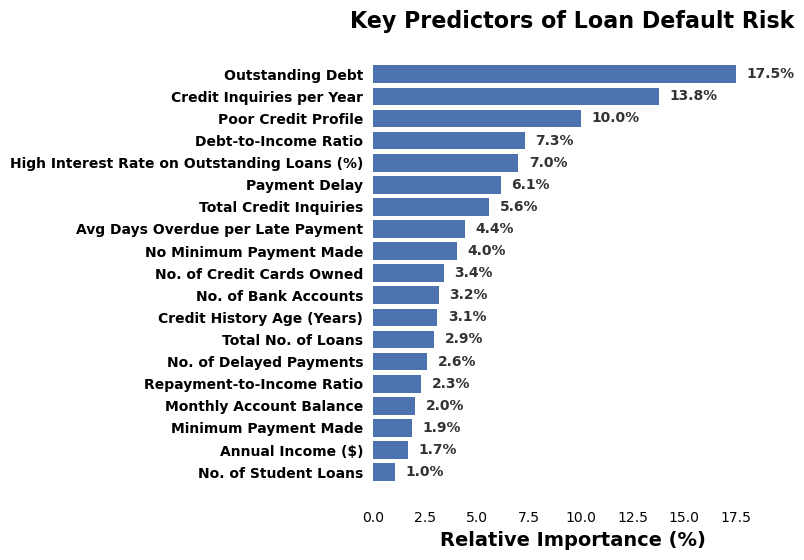

In [5]:
saved      = joblib.load("/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1.pkl")
pipe_final = saved["model"]  
clf         = pipe_final.named_steps["clf"]
importances = clf.feature_importances_

feat_names     = pipe_final.named_steps["pre"].get_feature_names_out()
mask           = pipe_final.named_steps["select"].get_support()
selected_feats = feat_names[mask]

# compute percentage importances 
imp_df = pd.DataFrame({
    "feature":    selected_feats,
    "importance": importances
})
imp_df["pct"] = imp_df["importance"] / imp_df["importance"].sum() * 100

label_map = {
    "num__Annual_Income":                  "Annual Income ($)",
    "num__Num_Bank_Accounts":              "No. of Bank Accounts",
    "num__Num_Credit_Card":                "No. of Credit Cards Owned",
    "num__Interest_Rate":                  "High Interest Rate on Outstanding Loans (%)",
    "num__Num_of_Loan":                    "Total No. of Loans",
    "num__Delay_from_due_date":            "Payment Delay",
    "num__Num_of_Delayed_Payment":         "No. of Delayed Payments",
    "num__Num_Credit_Inquiries":           "Total Credit Inquiries",
    "num__Outstanding_Debt":               "Outstanding Debt",
    "num__days_overdue_per_late_payment":  "Avg Days Overdue per Late Payment",
    "num__Credit_History_Age_num":         "Credit History Age (Years)",
    "num__debt_to_income_ratio":           "Debt-to-Income Ratio",
    "num__monthly_repayment_to_income":    "Repayment-to-Income Ratio",
    "num__credit_inquiries_per_year":      "Credit Inquiries per Year",
    # "num__Mortgage_Loan_count":            "No. of Mortgage Loans",
    "num__Student_Loan_count":             "No. of Student Loans",
    "cat__Credit_Mix_Bad":                 "Poor Credit Profile",
    "cat__Payment_of_Min_Amount_No":       "No Minimum Payment Made",
    "cat__Payment_of_Min_Amount_Yes":      "Minimum Payment Made",
    "num__Monthly_Balance":                "Monthly Account Balance",
}

imp_df["label"] = imp_df["feature"].map(label_map)
imp_df["label"] = imp_df["label"].fillna(imp_df["feature"])
plot_df = imp_df.sort_values("pct", ascending=False)

# Plot 
fig, ax = plt.subplots(figsize=(8, len(plot_df) * 0.3))
bars = ax.barh(plot_df["label"], plot_df["pct"], color="#4C72B0")
ax.invert_yaxis()

for bar in bars:
    w = bar.get_width()
    ax.text(
        w + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"{w:.1f}%",
        va="center", ha="left",
        fontsize=10, fontweight="bold", color="#333"
    )


for lbl in ax.get_yticklabels():
    lbl.set_fontweight("bold")


ax.set_title(
    "Key Predictors of Loan Default Risk",
    fontsize=16, fontweight="bold", pad=12
)
ax.set_xlabel("Relative Importance (%)", fontsize=14, fontweight="bold")
ax.set_xlim(0, plot_df["pct"].max() * 1.1)


ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.xaxis.set_ticks_position("none")
ax.yaxis.set_ticks_position("none")

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.1 when using v

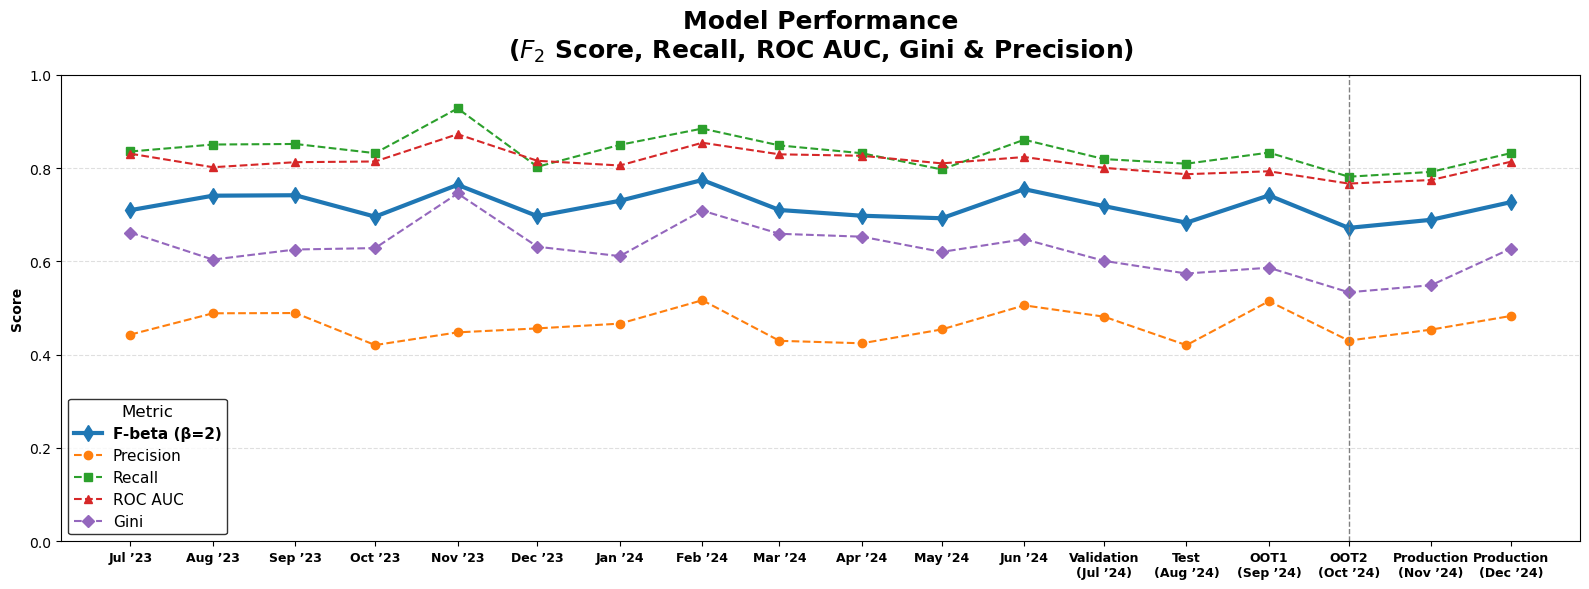

In [6]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, fbeta_score, roc_auc_score
import matplotlib as mpl

mpl.rcParams['font.family'] = 'DejaVu Sans'


df = pd.read_csv(
    '/Users/paulineng/Desktop/MLE_Assignment_2/final_merged_1.csv',
    parse_dates=['snapshot_date'], low_memory=False
)

train_start = pd.Timestamp(2023, 7, 1)
train_end   = train_start + pd.DateOffset(months=11)

split_dates = {
    "VAL":      train_end + pd.DateOffset(months=1),
    "TEST":     train_end + pd.DateOffset(months=2),
    "OOT1":     train_end + pd.DateOffset(months=3),
    "OOT2":     train_end + pd.DateOffset(months=4),
    "PROD_NOV": train_end + pd.DateOffset(months=5),
    "PROD_DEC": train_end + pd.DateOffset(months=6),
}

drop_cols = ['Customer_ID','snapshot_date','label_def','loan_id','Name','SSN']
features  = [c for c in df.columns if c not in drop_cols + ['label']]

train_df = df[
    (df.snapshot_date >= train_start) &
    (df.snapshot_date <= train_end)
].copy()

split_dfs = {
    name: df[df.snapshot_date == date].copy()
    for name, date in split_dates.items()
}

loaded = joblib.load("/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1.pkl")
pipe   = loaded["model"]    # <-- extract the pipeline here
best_thresh = 0.32
best_thresh = 0.32


train_df['month'] = train_df.snapshot_date.dt.to_period('M')
monthly = []
for period, grp in train_df.groupby('month'):
    Xg, yg = grp[features], grp['label']
    proba  = pipe.predict_proba(Xg)[:,1]
    preds  = (proba >= best_thresh).astype(int)
    monthly.append({
        "Split":         period.strftime("%b ’%y"),
        "Date":          period.to_timestamp(),
        "Precision":     precision_score(yg, preds, zero_division=0),
        "Recall":        recall_score(yg, preds),
        "F-beta (β=2)":  fbeta_score(yg, preds, beta=2),
        "ROC AUC":       roc_auc_score(yg, proba),
        "Gini":          2*roc_auc_score(yg, proba) - 1
    })
df_train_monthly = pd.DataFrame(monthly)


split_rows = []
for name, sdf in split_dfs.items():
    Xs, ys = sdf[features], sdf['label']
    proba   = pipe.predict_proba(Xs)[:,1]
    preds   = (proba >= best_thresh).astype(int)
    split_rows.append({
        "Split":         name,
        "Date":          sdf.snapshot_date.iloc[0],
        "Precision":     precision_score(ys, preds, zero_division=0),
        "Recall":        recall_score(ys, preds),
        "F-beta (β=2)":  fbeta_score(ys, preds, beta=2),
        "ROC AUC":       roc_auc_score(ys, proba),
        "Gini":          2*roc_auc_score(ys, proba) - 1
    })
df_splits = pd.DataFrame(split_rows)


df_all = pd.concat([df_train_monthly, df_splits], ignore_index=True)
df_all = df_all.sort_values('Date').reset_index(drop=True)


styles = {
    "F-beta (β=2)": {"fmt": "-d",  "lw": 3,   "ms": 8, "col": "C0"},
    "Precision":    {"fmt": "--o", "lw": 1.5, "ms": 6, "col": "C1"},
    "Recall":       {"fmt": "--s", "lw": 1.5, "ms": 6, "col": "C2"},
    "ROC AUC":      {"fmt": "--^", "lw": 1.5, "ms": 6, "col": "C3"},
    "Gini":         {"fmt": "--D", "lw": 1.5, "ms": 6, "col": "C4"},
}
metrics = ["F-beta (β=2)", "Precision", "Recall", "ROC AUC", "Gini"]


fig, ax = plt.subplots(figsize=(16, 6)) 

for m in metrics:
    s = styles[m]
    ax.plot(
        df_all["Date"], df_all[m],
        s["fmt"], color=s["col"],
        linewidth=s["lw"], markersize=s["ms"],
        label=m
    )

ax.axvline(split_dates["OOT2"], color="gray", linestyle="--", linewidth=1)

display_map = {
    "VAL":      "Validation",
    "TEST":     "Test",
    "OOT1":     "OOT1",
    "OOT2":     "OOT2",
    "PROD_NOV": "Production",
    "PROD_DEC": "Production"
}
month_map = {
    "VAL":      "Jul ’24",
    "TEST":     "Aug ’24",
    "OOT1":     "Sep ’24",
    "OOT2":     "Oct ’24",
    "PROD_NOV": "Nov ’24",
    "PROD_DEC": "Dec ’24"
}

labels = []
for sp, dt in zip(df_all["Split"], df_all["Date"]):
    if sp in df_train_monthly["Split"].values:
        labels.append(sp)
    else:
        labels.append(f"{display_map[sp]}\n({month_map[sp]})")

ax.set_xticks(df_all["Date"])
ax.set_xticklabels(labels, rotation=0, ha="center",
                   fontweight="bold", fontsize=9)  

ax.set_title(
    "Model Performance\n($F_2$ Score, Recall, ROC AUC, Gini & Precision)",
    fontsize=18, fontweight="bold", pad=12
)
ax.set_ylabel("Score", fontweight="bold")
ax.set_ylim(0, 1)
ax.grid(axis="y", linestyle="--", alpha=0.4)

leg = ax.legend(title="Metric", frameon=True, loc="lower left", fontsize=10, title_fontsize=12)
leg.get_frame().set_edgecolor("black")
for txt in leg.get_texts():
    txt.set_fontsize(11)
    if txt.get_text() == "F-beta (β=2)":
        txt.set_fontweight("bold")
    else:
        txt.set_fontweight("normal")

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.1 when using v

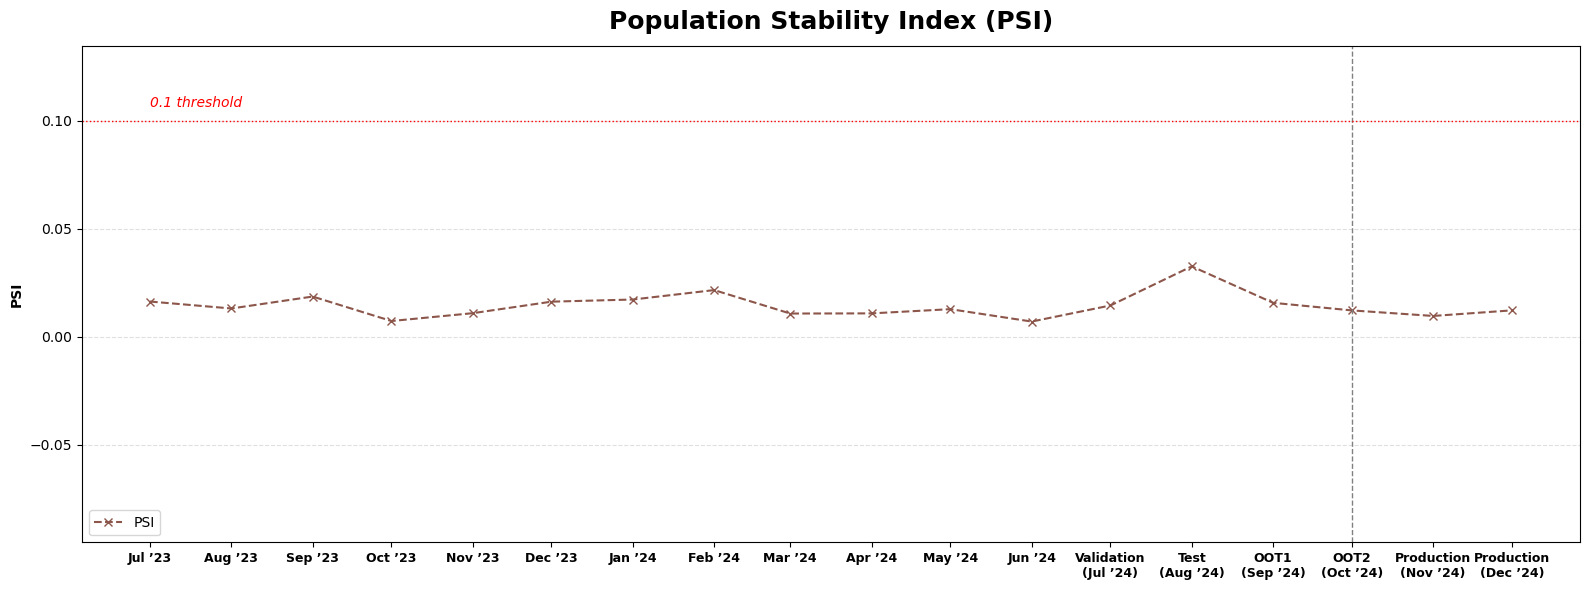

In [7]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import precision_score, recall_score, fbeta_score, roc_auc_score


def compute_psi(ref_dist: np.ndarray, cur_scores: np.ndarray, bin_edges: np.ndarray) -> float:
    """
    Compute the Population Stability Index between a fixed reference distribution
    and a new set of model scores.
    """
    cur_counts, _ = np.histogram(cur_scores, bins=bin_edges)
    cur_dist = cur_counts / cur_scores.size
    cur_dist = np.where(cur_dist == 0, 1e-6, cur_dist)  # floor zeros
    psi_vals = (cur_dist - ref_dist) * np.log(cur_dist / ref_dist)
    return psi_vals.sum()


mpl.rcParams['font.family'] = 'DejaVu Sans'


df = pd.read_csv(
    '/Users/paulineng/Desktop/MLE_Assignment_2/final_merged_1.csv',
    parse_dates=['snapshot_date'], low_memory=False
)

train_start = pd.Timestamp(2023, 7, 1)
train_end   = train_start + pd.DateOffset(months=11)

split_dates = {
    "VAL":      train_end + pd.DateOffset(months=1),
    "TEST":     train_end + pd.DateOffset(months=2),
    "OOT1":     train_end + pd.DateOffset(months=3),
    "OOT2":     train_end + pd.DateOffset(months=4),
    "PROD_NOV": train_end + pd.DateOffset(months=5),
    "PROD_DEC": train_end + pd.DateOffset(months=6),
}

drop_cols = ['Customer_ID','snapshot_date','label_def','loan_id','Name','SSN']
features  = [c for c in df.columns if c not in drop_cols + ['label']]

train_df = df[
    (df.snapshot_date >= train_start) &
    (df.snapshot_date <= train_end)
].copy()

split_dfs = {
    name: df[df.snapshot_date == date].copy()
    for name, date in split_dates.items()
}


loaded = joblib.load("/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1.pkl")
pipe   = loaded["model"]    # <-- extract the pipeline here
best_thresh = 0.32
best_thresh = 0.32

bin_edges   = np.linspace(0, 1, 11)  # 10 equal-width bins
train_proba = pipe.predict_proba(train_df[features])[:,1]
ref_counts, _ = np.histogram(train_proba, bins=bin_edges)
ref_dist      = ref_counts / train_proba.size
ref_dist      = np.where(ref_dist == 0, 1e-6, ref_dist)

train_df['month'] = train_df.snapshot_date.dt.to_period('M')
monthly = []
for period, grp in train_df.groupby('month'):
    proba   = pipe.predict_proba(grp[features])[:,1]
    psi_val = compute_psi(ref_dist, proba, bin_edges)
    monthly.append({
        "Split": period.strftime("%b ’%y"),
        "Date":  period.to_timestamp(),
        "PSI":   psi_val
    })
df_train_monthly = pd.DataFrame(monthly)

split_rows = []
for name, sdf in split_dfs.items():
    proba   = pipe.predict_proba(sdf[features])[:,1]
    psi_val = compute_psi(ref_dist, proba, bin_edges)
    split_rows.append({
        "Split": name,
        "Date":  sdf.snapshot_date.iloc[0],
        "PSI":   psi_val
    })
df_splits = pd.DataFrame(split_rows)

df_all = pd.concat([df_train_monthly, df_splits], ignore_index=True)
df_all = df_all.sort_values('Date').reset_index(drop=True)

display_map = {
    "VAL":      "Validation",
    "TEST":     "Test",
    "OOT1":     "OOT1",
    "OOT2":     "OOT2",
    "PROD_NOV": "Production",
    "PROD_DEC": "Production"
}
month_map = {
    "VAL":      "Jul ’24",
    "TEST":     "Aug ’24",
    "OOT1":     "Sep ’24",
    "OOT2":     "Oct ’24",
    "PROD_NOV": "Nov ’24",
    "PROD_DEC": "Dec ’24"
}
labels = []
for sp in df_all["Split"]:
    if sp in df_train_monthly["Split"].values:
        labels.append(sp)
    else:
        labels.append(f"{display_map[sp]}\n({month_map[sp]})")


fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(
    df_all["Date"],
    df_all["PSI"],
    "--x", linewidth=1.5, markersize=6, color="C5", label="PSI"
)

ax.axvline(split_dates["OOT2"], color="gray", linestyle="--", linewidth=1)

upper = df_all["PSI"].max() * 1.1
ax.set_ylim(0, upper)

ax.axhline(0.1, color="red", linestyle=":", linewidth=1)
ax.text(df_all["Date"].iloc[0], 0.105, "0.1 threshold",
        color="red", va="bottom", fontstyle="italic")

ax.set_xticks(df_all["Date"])
ax.set_xticklabels(
    labels, rotation=0, ha="center",
    fontweight="bold", fontsize=9
)

ax.set_title(
    "Population Stability Index (PSI)",
    fontsize=18, fontweight="bold", pad=12
)
ax.set_ylabel("PSI", fontweight="bold")

min_psi, max_psi = df_all["PSI"].min(), df_all["PSI"].max()
pad = (max_psi - min_psi) * 4
ax.set_ylim(min_psi - pad, max_psi + pad)

ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(frameon=True, loc="lower left", fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.show()

In [8]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.metrics import precision_score, recall_score, fbeta_score, confusion_matrix  # ← added confusion_matrix

/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.1 when using v

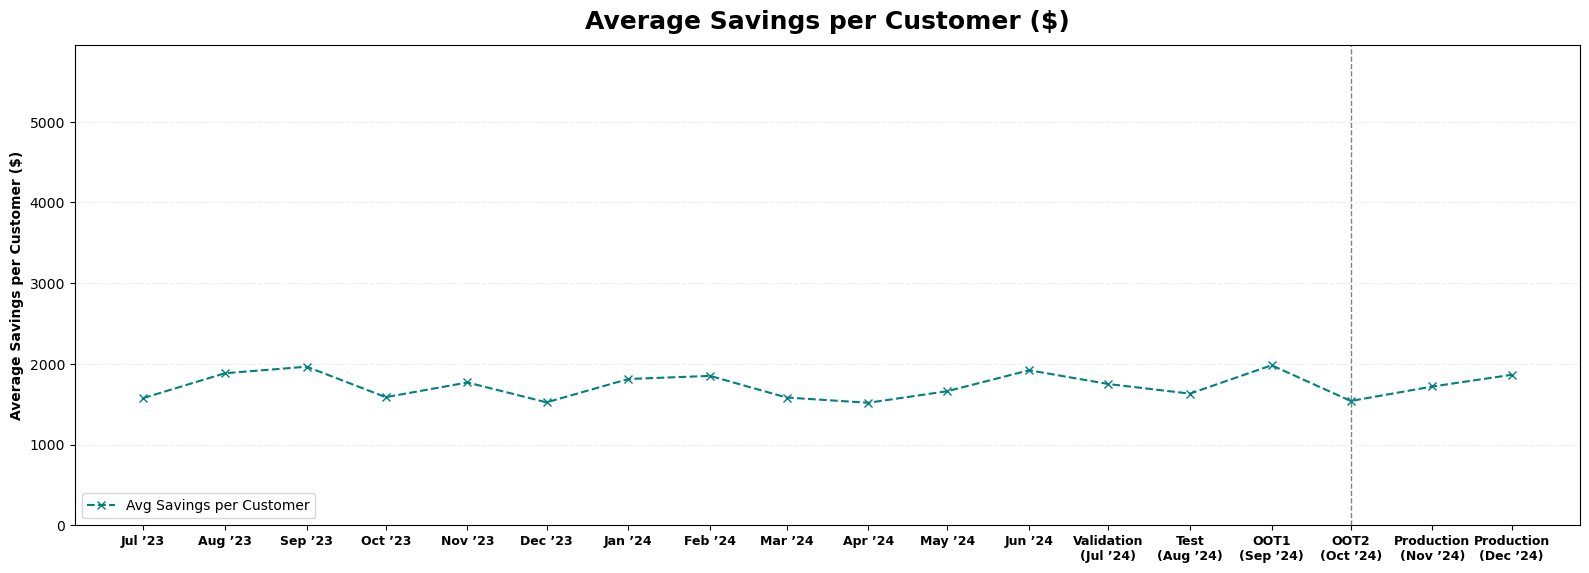

In [9]:
mpl.rcParams['font.family'] = 'DejaVu Sans'

df = pd.read_csv(
    '/Users/paulineng/Desktop/MLE_Assignment_2/final_merged_1.csv',
    parse_dates=['snapshot_date'], low_memory=False
)

train_start = pd.Timestamp(2023, 7, 1)
train_end   = train_start + pd.DateOffset(months=11)

split_dates = {
    "VAL":      train_end + pd.DateOffset(months=1),
    "TEST":     train_end + pd.DateOffset(months=2),
    "OOT1":     train_end + pd.DateOffset(months=3),
    "OOT2":     train_end + pd.DateOffset(months=4),
    "PROD_NOV": train_end + pd.DateOffset(months=5),
    "PROD_DEC": train_end + pd.DateOffset(months=6),
}

drop_cols = ['Customer_ID','snapshot_date','label_def','loan_id','Name','SSN']
features  = [c for c in df.columns if c not in drop_cols + ['label']]

train_df = df[
    (df.snapshot_date >= train_start) &
    (df.snapshot_date <= train_end)
].copy()

split_dfs = {
    name: df[df.snapshot_date == date].copy()
    for name, date in split_dates.items()
}

loaded      = joblib.load("/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1.pkl")
pipe        = loaded["model"]
best_thresh = loaded.get("threshold", 0.32)


C_FP = 311   # cost per false positive
C_FN = 7530  # cost per false negative

train_df['month'] = train_df.snapshot_date.dt.to_period('M')
monthly_rows = []
for period, grp in train_df.groupby('month'):
    y       = grp['label']
    proba   = pipe.predict_proba(grp[features])[:,1]
    preds   = (proba >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    baseline = y.sum() * C_FN
    cost     = fp * C_FP + fn * C_FN
    avg_sav  = (baseline - cost) / len(y)
    monthly_rows.append({
        "Split":      period.strftime("%b ’%y"),
        "Date":       period.to_timestamp(),
        "AvgSavings": avg_sav
    })


split_rows = []
for name, sdf in split_dfs.items():
    y       = sdf['label']
    proba   = pipe.predict_proba(sdf[features])[:,1]
    preds   = (proba >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, preds).ravel()
    baseline = y.sum() * C_FN
    cost     = fp * C_FP + fn * C_FN
    avg_sav  = (baseline - cost) / len(y)
    split_rows.append({
        "Split":      name,
        "Date":       sdf.snapshot_date.iloc[0],
        "AvgSavings": avg_sav
    })

df_sav = pd.DataFrame(monthly_rows + split_rows).sort_values('Date').reset_index(drop=True)

display_map = {
    "VAL":      "Validation",
    "TEST":     "Test",
    "OOT1":     "OOT1",
    "OOT2":     "OOT2",
    "PROD_NOV": "Production",
    "PROD_DEC": "Production"
}
month_map = {
    "VAL":      "Jul ’24",
    "TEST":     "Aug ’24",
    "OOT1":     "Sep ’24",
    "OOT2":     "Oct ’24",
    "PROD_NOV": "Nov ’24",
    "PROD_DEC": "Dec ’24"
}
labels = []
for sp in df_sav["Split"]:
    if sp in [r["Split"] for r in monthly_rows]:
        labels.append(sp)
    else:
        labels.append(f"{display_map[sp]}\n({month_map[sp]})")

fig, ax = plt.subplots(figsize=(16, 6))

# Plot line
ax.plot(
    df_sav["Date"],
    df_sav["AvgSavings"],
    "--x", linewidth=1.5, markersize=6,
    color="teal", label="Avg Savings per Customer"
)

# Vertical line at OOT2
ax.axvline(split_dates["OOT2"], color="gray", linestyle="--", linewidth=1)

# X-ticks & labels
ax.set_xticks(df_sav["Date"])
ax.set_xticklabels(
    labels, rotation=0, ha="center",
    fontweight="bold", fontsize=9
)

# Title & y-axis label
ax.set_title(
    "Average Savings per Customer ($)",
    fontsize=18, fontweight="bold", pad=12
)
ax.set_ylabel("Average Savings per Customer ($)", fontweight="bold")

ax.set_ylim(0, df_sav["AvgSavings"].max() * 3)

# Grid & legend
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.legend(frameon=True, loc="lower left", fontsize=10, title_fontsize=12)

plt.tight_layout()
plt.subplots_adjust(top=0.92, bottom=0.12)
plt.show()

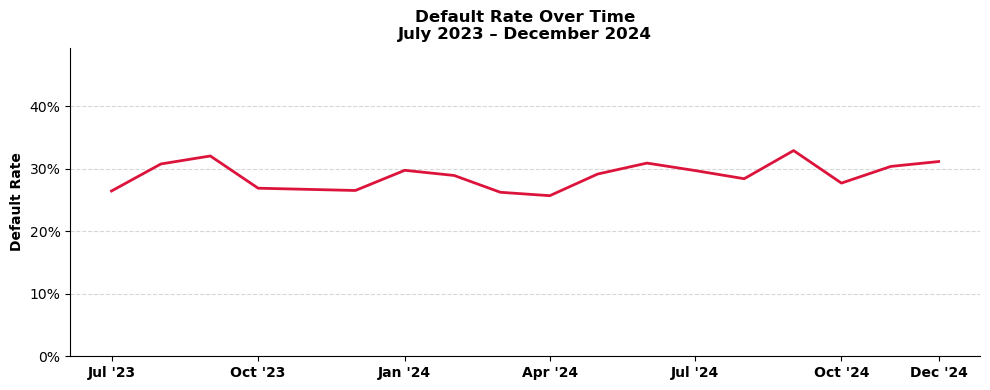

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from pathlib import Path

label_dir = Path("/Users/paulineng/MLE/MLEA2/scripts/datamart/gold/label_store")
date_col  = 'snapshot_date'
label_col = 'label'

# Load & Concatenate Parquet Labels 
parquet_files = list(label_dir.glob("*.parquet"))
df = pd.concat(
    (pd.read_parquet(f) for f in parquet_files),
    ignore_index=True
)
df[date_col] = pd.to_datetime(df[date_col])

df = df[(df[date_col] >= '2023-07-01') & (df[date_col] <= '2024-12-31')]

df['month'] = df[date_col].dt.to_period('M').dt.to_timestamp()
monthly = (
    df
    .groupby('month')[label_col]
    .mean()
    .reset_index()
    .rename(columns={label_col: 'default_rate'})
)

fig, ax = plt.subplots(figsize=(10, 4))

# raw line
ax.plot(
    monthly['month'],
    monthly['default_rate'],
    color='crimson', linewidth=2,
    label='Monthly'
)

# title & labels
ax.set_title("Default Rate Over Time\nJuly 2023 – December 2024", fontweight='bold')
ax.set_ylabel('Default Rate', fontweight='bold')

# x-ticks every 3 months + include last month
ticks = list(monthly['month'][::3]) + [monthly['month'].iloc[-1]]
ax.set_xticks(ticks)
ax.set_xticklabels([t.strftime("%b '%y") for t in ticks], fontweight='bold')

# percent formatting on y-axis
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))

# zoom out y-axis so 1–2 pp swings look smaller
ax.set_ylim(0, monthly['default_rate'].max() * 1.5)

# grid & spines
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.1 when using v

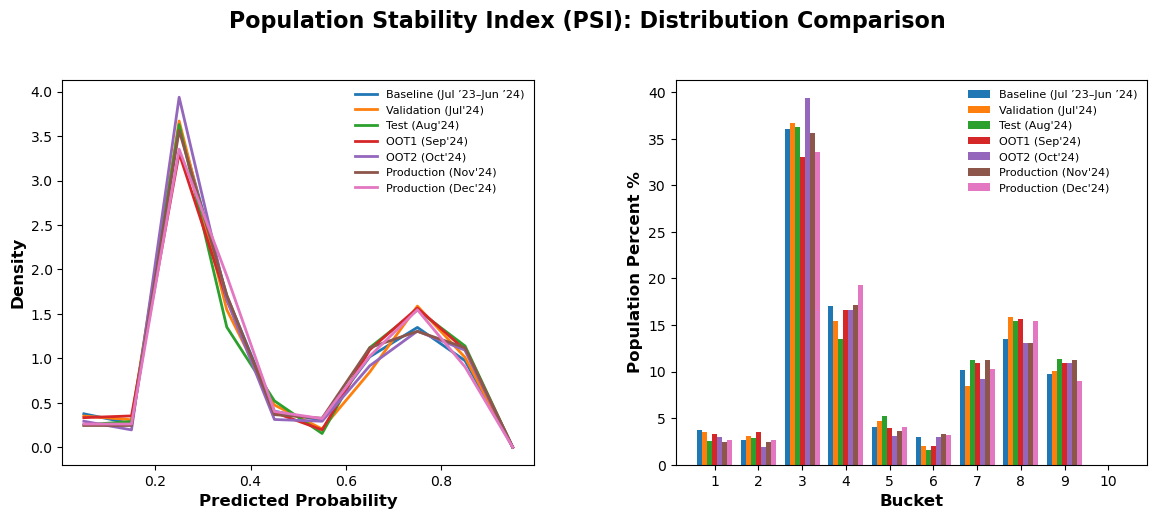

In [11]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib as mpl


DATA_PATH  = '/Users/paulineng/Desktop/MLE_Assignment_2/final_merged_1.csv'
MODEL_PATH = '/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1.pkl'
DATE_COL   = 'snapshot_date'
DROP_COLS  = ['Customer_ID','label_def','loan_id','Name','SSN']


mpl.rcParams['font.family'] = 'DejaVu Sans'
plt.rc('axes', titlesize=14, titleweight='bold')
plt.rc('axes', labelsize=12, labelweight='bold')


df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL], low_memory=False)
loaded = joblib.load(MODEL_PATH)
pipe   = loaded['model']  # adjust key if different


train_start = pd.Timestamp(2023, 7, 1)
train_end   = train_start + pd.DateOffset(months=11)
split_dates = {
    "Validation (Jul'24)": train_end + pd.DateOffset(months=1),  # Jun ’24
    "Test (Aug'24)":       train_end + pd.DateOffset(months=2),  # Jul ’24
    "OOT1 (Sep'24)":       train_end + pd.DateOffset(months=3),  # Aug ’24
    "OOT2 (Oct'24)":       train_end + pd.DateOffset(months=4),  # Sep ’24
    "Production (Nov'24)":   train_end + pd.DateOffset(months=5),  # Oct ’24
    "Production (Dec'24)":   train_end + pd.DateOffset(months=6),  # Nov ’24
}


features = [c for c in df.columns if c not in DROP_COLS + [DATE_COL, 'label']]


train_df  = df[(df[DATE_COL] >= train_start) & (df[DATE_COL] <= train_end)].copy()
split_dfs = {name: df[df[DATE_COL] == date].copy() for name, date in split_dates.items()}


baseline = pipe.predict_proba(train_df[features])[:, 1]
bins        = np.linspace(0, 1, 11)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width   = bins[1] - bins[0]

base_counts, _ = np.histogram(baseline, bins=bins)
base_pct       = base_counts / base_counts.sum()
base_density   = base_pct / bin_width


densities   = {"Baseline (Jul ’23–Jun ’24)": base_density}
percentages = {"Baseline (Jul ’23–Jun ’24)": base_pct}

for name in split_dates:
    proba = pipe.predict_proba(split_dfs[name][features])[:, 1]
    counts, _ = np.histogram(proba, bins=bins)
    pct = counts / counts.sum()
    densities[name]   = pct / bin_width
    percentages[name] = pct


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'wspace':0.3})
fig.suptitle("Population Stability Index (PSI): Distribution Comparison", fontsize=16, fontweight='bold', y=1.02)

for label, dens in densities.items():
    ax1.plot(bin_centers, dens, label=label, linewidth=2)

ax1.set_xlabel("Predicted Probability")
ax1.set_ylabel("Density")
ax1.legend(frameon=False, fontsize=8)


labels = list(percentages.keys())
n_series = len(labels)
width = 0.8 / n_series


buckets = np.arange(1, 11)

for i, label in enumerate(labels):
    vals = percentages[label] * 100
    offset = (i - n_series/2) * width + width/2
    ax2.bar(buckets + offset, vals, width=width, label=label)

ax2.set_xlabel("Bucket")
ax2.set_ylabel("Population Percent %")
ax2.set_xticks(buckets)
ax2.set_xticklabels([str(i) for i in buckets])
ax2.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

Using features: ['Annual_Income', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Monthly_Balance', 'days_overdue_per_late_payment', 'Credit_History_Age_num', 'debt_to_income_ratio', 'monthly_repayment_to_income', 'credit_inquiries_per_year', 'Student_Loan_count']


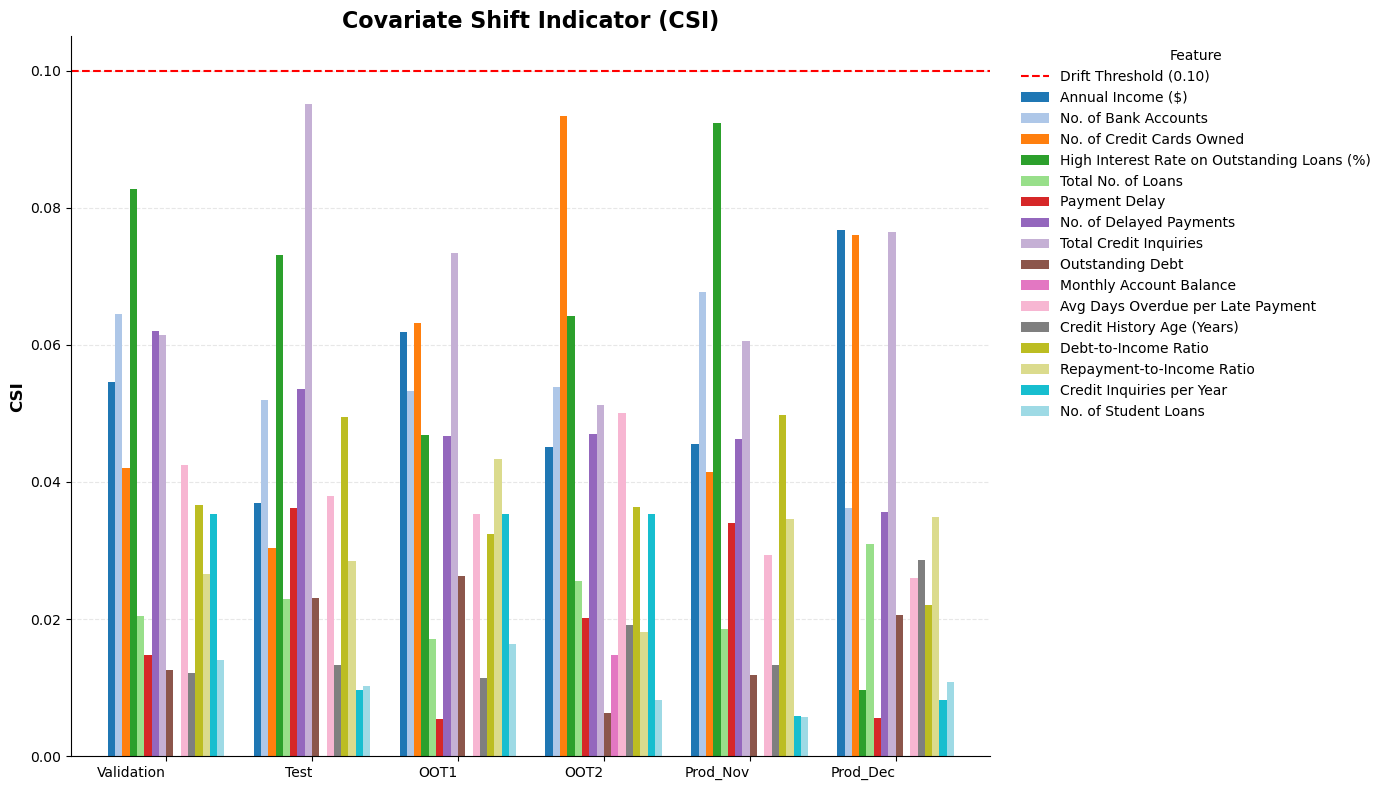

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH  = '/Users/paulineng/Desktop/MLE_Assignment_2/final_merged_1.csv'  
DATE_COL   = 'snapshot_date'
DROP_COLS  = ['Customer_ID','label_def','loan_id','Name','SSN','label']

df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL], low_memory=False)

train_start = pd.Timestamp(2023, 7, 1)
train_end   = train_start + pd.DateOffset(months=11)

split_dates = {
    "Validation": train_end + pd.DateOffset(months=1),
    "Test":       train_end + pd.DateOffset(months=2),
    "OOT1":       train_end + pd.DateOffset(months=3),
    "OOT2":       train_end + pd.DateOffset(months=4),
    "Prod_Nov":   train_end + pd.DateOffset(months=5),
    "Prod_Dec":   train_end + pd.DateOffset(months=6),
}


train_df = df[(df[DATE_COL] >= train_start) & (df[DATE_COL] <= train_end)].copy()
split_dfs = {name: df[df[DATE_COL] == date].copy() for name, date in split_dates.items()}

requested = [
    'Annual_Income','Num_Bank_Accounts','Num_Credit_Card','Interest_Rate',
    'Num_of_Loan','Delay_from_due_date','Num_of_Delayed_Payment',
    'Num_Credit_Inquiries','Outstanding_Debt','Monthly_Balance',
    'days_overdue_per_late_payment','Credit_History_Age_num',
    'debt_to_income_ratio','monthly_repayment_to_income',
    'credit_inquiries_per_year','Student_Loan_count',
    'Credit_Mix_Bad','Payment_of_Min_Amount_No','Payment_of_Min_Amount_Yes'
]
features = [f for f in requested if f in train_df.columns]

print("Using features:", features)


def compute_psi(ref_dist: np.ndarray, new_vals: np.ndarray, bins: np.ndarray) -> float:
    counts, _ = np.histogram(new_vals, bins=bins)
    dist = counts / counts.sum()
    dist = np.where(dist == 0, 1e-6, dist)
    return ((dist - ref_dist) * np.log(dist / ref_dist)).sum()


psi_results = {phase: {} for phase in split_dfs}

for feat in features:
    all_vals = np.concatenate([
        train_df[feat].dropna().values,
        *(sdf[feat].dropna().values for sdf in split_dfs.values())
    ])
    bins = np.linspace(all_vals.min(), all_vals.max(), 11)

    ref_counts, _ = np.histogram(train_df[feat].dropna(), bins=bins)
    ref_dist = ref_counts / ref_counts.sum()
    ref_dist = np.where(ref_dist == 0, 1e-6, ref_dist)

    for phase, sdf in split_dfs.items():
        new_vals = sdf[feat].dropna().values
        psi_results[phase][feat] = compute_psi(ref_dist, new_vals, bins)

psi_df = pd.DataFrame(psi_results).T


maplabel_map = {
    "num__Annual_Income":                  "Annual Income ($)",
    "num__Num_Bank_Accounts":              "No. of Bank Accounts",
    "num__Num_Credit_Card":                "No. of Credit Cards Owned",
    "num__Interest_Rate":                  "High Interest Rate on Outstanding Loans (%)",
    "num__Num_of_Loan":                    "Total No. of Loans",
    "num__Delay_from_due_date":            "Payment Delay",
    "num__Num_of_Delayed_Payment":         "No. of Delayed Payments",
    "num__Num_Credit_Inquiries":           "Total Credit Inquiries",
    "num__Outstanding_Debt":               "Outstanding Debt",
    "num__days_overdue_per_late_payment":  "Avg Days Overdue per Late Payment",
    "num__Credit_History_Age_num":         "Credit History Age (Years)",
    "num__debt_to_income_ratio":           "Debt-to-Income Ratio",
    "num__monthly_repayment_to_income":    "Repayment-to-Income Ratio",
    "num__credit_inquiries_per_year":      "Credit Inquiries per Year",
    "num__Student_Loan_count":             "No. of Student Loans",
    "cat__Credit_Mix_Bad":                 "Poor Credit Profile",
    "cat__Payment_of_Min_Amount_No":       "No Minimum Payment Made",
    "cat__Payment_of_Min_Amount_Yes":      "Minimum Payment Made",
    "num__Monthly_Balance":                "Monthly Account Balance",
}

raw2friendly = {
    full.split("__", 1)[1]: friendly
    for full, friendly in maplabel_map.items()
}
psi_df_friendly = psi_df.rename(columns=raw2friendly)

fig, ax = plt.subplots(figsize=(14, 8), facecolor='white')
ax.set_facecolor('white')

psi_df_friendly.plot(
    kind='bar',
    width=0.8,
    colormap='tab20',
    ax=ax,
    legend=True
)

ax.axhline(0.10, color='red', linestyle='--', lw=1.5, label='Drift Threshold (0.10)')


for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)


ax.legend(
    title="Feature",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)
ax.set_xlabel("")  
ax.set_ylabel("CSI", fontweight="bold")
ax.set_title("Covariate Shift Indicator (CSI)", fontsize=16, fontweight="bold")
plt.xticks(rotation=0, ha="right")
plt.tight_layout()
plt.show()

/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.1 when using v

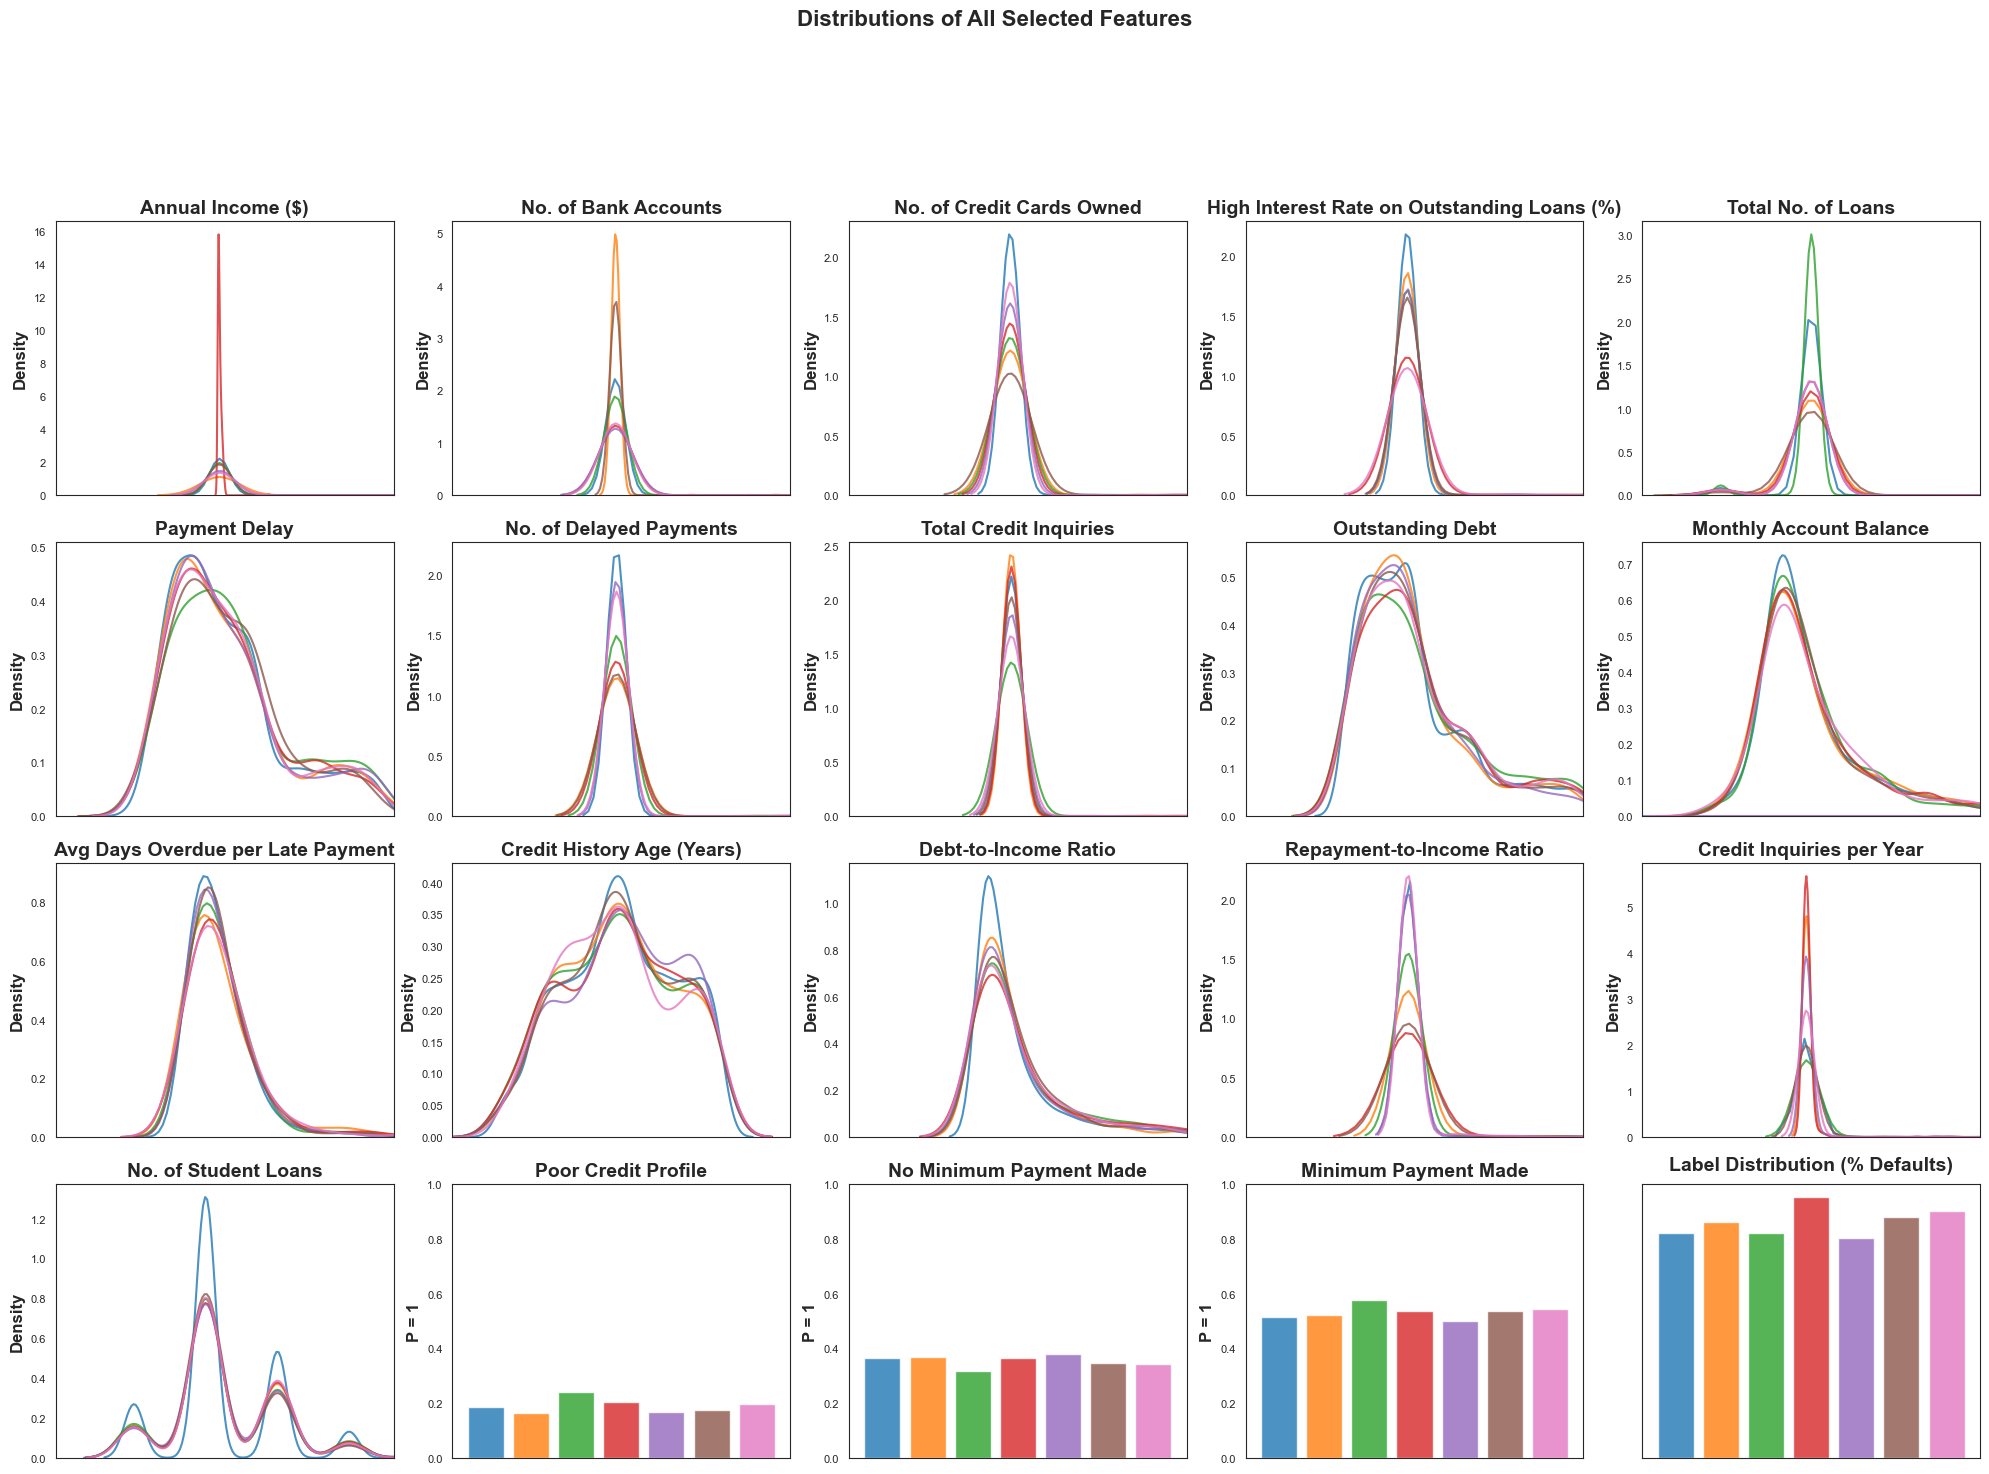

In [13]:
import joblib
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(
    '/Users/paulineng/Desktop/MLE_Assignment_2/final_merged_1.csv',
    parse_dates=['snapshot_date'],
    low_memory=False
)

saved      = joblib.load("/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1.pkl")
pipe_final = saved["model"]   # extract the Pipeline
feat_names = pipe_final.named_steps["pre"].get_feature_names_out()
mask       = pipe_final.named_steps["select"].get_support()
selected_feats = feat_names[mask]  # your 19 features

train_start = pd.Timestamp(2023, 7, 1)
train_end   = train_start + pd.DateOffset(months=11)

split_dates = {
    "VAL":      train_end + pd.DateOffset(months=1),
    "TEST":     train_end + pd.DateOffset(months=2),
    "OOT1":     train_end + pd.DateOffset(months=3),
    "OOT2":     train_end + pd.DateOffset(months=4),
    "PROD_NOV": train_end + pd.DateOffset(months=5),
    "PROD_DEC": train_end + pd.DateOffset(months=6),
}

train_df = df[
    (df.snapshot_date >= train_start) &
    (df.snapshot_date <= train_end)
].copy()

split_dfs = {
    name: df[df.snapshot_date == date].copy()
    for name, date in split_dates.items()
}

X_train = train_df.copy();          y_train = train_df['label']
X_val   = split_dfs["VAL"].copy();  y_val   = X_val['label']
X_test  = split_dfs["TEST"].copy(); y_test  = X_test['label']
X_oot1  = split_dfs["OOT1"].copy(); y_oot1  = X_oot1['label']
X_oot2  = split_dfs["OOT2"].copy(); y_oot2  = X_oot2['label']
X_nov   = split_dfs["PROD_NOV"].copy(); y_nov   = X_nov['label']
X_dec   = split_dfs["PROD_DEC"].copy(); y_dec   = X_dec['label']


numeric_feats = [f.replace("num__", "") for f in selected_feats if f.startswith("num__")]

scaler = StandardScaler().fit(X_train[numeric_feats])

splits = [
    ("Training",          X_train),
    ("Validation",        X_val),
    ("Test",              X_test),
    ("OOT1",              X_oot1),
    ("OOT2",              X_oot2),
    ("Production Nov'24", X_nov),
    ("Production Dec'24", X_dec),
]

numeric_splits = []
for name, df_ in splits:
    df_num = pd.DataFrame(
        scaler.transform(df_[numeric_feats]),
        columns=numeric_feats,
        index=df_.index
    )
    numeric_splits.append((name, df_num))

raw_splits = splits  

label_map = {
    "num__Annual_Income":                  "Annual Income ($)",
    "num__Num_Bank_Accounts":              "No. of Bank Accounts",
    "num__Num_Credit_Card":                "No. of Credit Cards Owned",
    "num__Interest_Rate":                  "High Interest Rate on Outstanding Loans (%)",
    "num__Num_of_Loan":                    "Total No. of Loans",
    "num__Delay_from_due_date":            "Payment Delay",
    "num__Num_of_Delayed_Payment":         "No. of Delayed Payments",
    "num__Num_Credit_Inquiries":           "Total Credit Inquiries",
    "num__Outstanding_Debt":               "Outstanding Debt",
    "num__days_overdue_per_late_payment":  "Avg Days Overdue per Late Payment",
    "num__Credit_History_Age_num":         "Credit History Age (Years)",
    "num__debt_to_income_ratio":           "Debt-to-Income Ratio",
    "num__monthly_repayment_to_income":    "Repayment-to-Income Ratio",
    "num__credit_inquiries_per_year":      "Credit Inquiries per Year",
    "num__Student_Loan_count":             "No. of Student Loans",
    "cat__Credit_Mix_Bad":                 "Poor Credit Profile",
    "cat__Payment_of_Min_Amount_No":       "No Minimum Payment Made",
    "cat__Payment_of_Min_Amount_Yes":      "Minimum Payment Made",
    "num__Monthly_Balance":                "Monthly Account Balance",
}
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = {name: default_colors[i] for i, (name, _) in enumerate(splits)}

sns.set_style("white")
n_feats = len(selected_feats)
n_cols  = 5
n_rows  = math.ceil((n_feats + 1) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(4*n_cols, 3.5*n_rows),
                         squeeze=False)
axes = axes.flatten()

for idx, feat in enumerate(selected_feats):
    ax = axes[idx]
    ax.grid(False)
    ax.set_xticks([])

    if feat.startswith("num__"):
        raw = feat.replace("num__", "")
        for name, df_num in numeric_splits:
            sns.kdeplot(
                df_num[raw].dropna(),
                ax=ax,
                color=colors[name],
                linewidth=1.5,
                alpha=0.8,
                fill=False
            )
        ax.set_xlim(-3, 3)
        if idx % n_cols == 0:
            ax.set_ylabel("Density", fontweight="bold")

    else:
        # for cat__Feature_val, split on last "_"
        orig_col, cat_val = feat[len("cat__"):].rsplit("_", 1)
        rates = {
            name: (df_[orig_col] == cat_val).mean()
            for name, df_ in raw_splits
        }
        ax.bar(
            range(len(rates)),
            list(rates.values()),
            color=[colors[n] for n in rates],
            alpha=0.8
        )
        ax.set_ylim(0, 1)
        ax.set_ylabel("P = 1", fontweight="bold")

    ax.set_title(label_map.get(feat, feat),
                 fontweight="bold", fontsize=14)
    ax.tick_params(axis="y", labelsize=8)

label_splits = [
    ("Training",          y_train),
    ("Validation",        y_val),
    ("Test",              y_test),
    ("OOT1",              y_oot1),
    ("OOT2",              y_oot2),
    ("Production Nov'24", y_nov),
    ("Production Dec'24", y_dec),
]
default_rates = [y.mean() for _, y in label_splits]

ax = axes[n_feats]
ax.bar(
    range(len(default_rates)),
    default_rates,
    color=[colors[name] for name, _ in label_splits],
    alpha=0.8
)
ax.set_title("Label Distribution (% Defaults)",
             fontsize=14, fontweight="bold", y=1.02)
ax.set_xticks([]); ax.set_yticks([])

for j in range(n_feats + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="upper center", ncol=len(splits),
           frameon=False, fontsize=12,
           bbox_to_anchor=(0.5, 1.02))

plt.suptitle("Distributions of All Selected Features",
             fontsize=16, fontweight="bold", y=1.05)
plt.tight_layout(rect=[0,0,1,0.95], h_pad=1.0, w_pad=0.5)
plt.show()

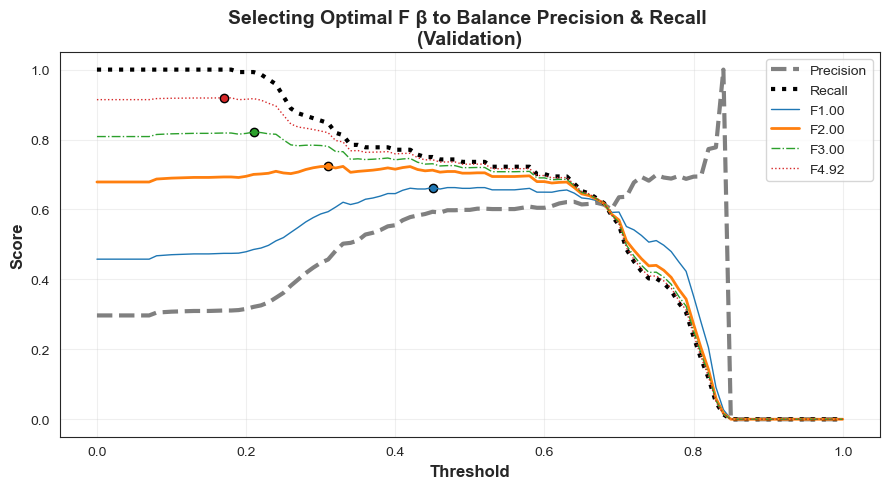

In [14]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, fbeta_score, confusion_matrix

probs      = pipe_final.predict_proba(X_val)[:, 1]
y_true     = y_val
thresholds = np.linspace(0, 1, 101)
baseline   = y_true.sum() * C_FN


precisions = [precision_score(y_true, (probs >= t).astype(int), zero_division=0)
              for t in thresholds]
recalls    = [recall_score(y_true, (probs >= t).astype(int))
              for t in thresholds]

# Compute Fβ for each beta
betas = [1.0, 2.0, 3.0, 4.92]
f_scores = {
    b: [fbeta_score(y_true, (probs >= t).astype(int), beta=b) for t in thresholds]
    for b in betas
}


peaks = {b: (thresholds[np.argmax(f_scores[b])], max(f_scores[b]))
         for b in betas}


fig, ax = plt.subplots(figsize=(9, 5))

# Precision & Recall
ax.plot(thresholds, precisions, '--', color='gray', linewidth=3, label='Precision')
ax.plot(thresholds, recalls,    ':',  color='black', linewidth=3, label='Recall')

# Fβ curves
styles = {1.0: '-', 2.0: '-', 3.0: '-.', 4.92: ':'}
widths = {1.0: 1,   2.0: 2,   3.0: 1,   4.92: 1}
for b in betas:
    ax.plot(thresholds, f_scores[b],
            linestyle=styles[b],
            linewidth=widths[b],
            label=f'F{b:.2f}')
    thr, val = peaks[b]
    ax.scatter(thr, val, edgecolor='k')
    # ax.annotate(f'β={b:.2f}\nthr={thr:.2f}\nF={val:.2f}',
    #             xy=(thr, val),
    #             xytext=(thr + 0.02, val - 0.05),
    #             fontsize=8,
    #             arrowprops=dict(arrowstyle='->'))

ax.set_xlabel('Threshold', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title(
    'Selecting Optimal F β to Balance Precision & Recall \n(Validation)',
    fontweight='bold'
)
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
plt.show()

/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.6.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/miniconda3/envs/demoo/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator ColumnTransformer from version 1.6.1 when using v

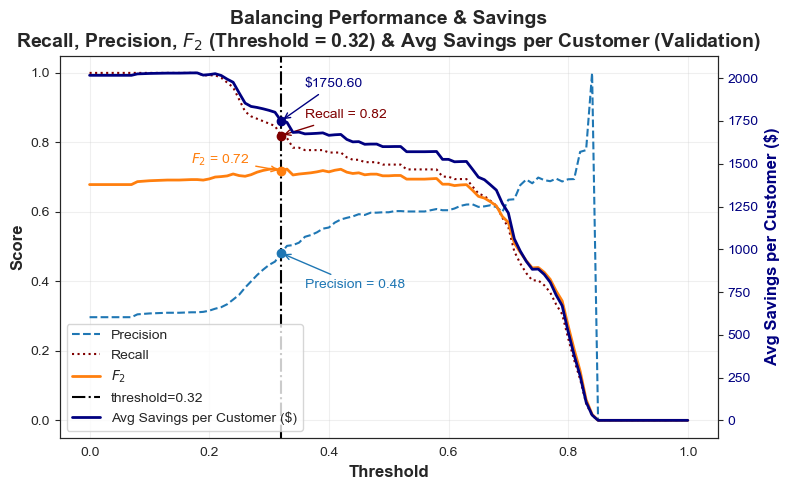

In [15]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.metrics import precision_score, recall_score, fbeta_score, confusion_matrix

data        = joblib.load("/Users/paulineng/Desktop/MLE_Assignment_2/xgboostv1.pkl")
# pipe_final  = data["pipeline"]
best_thresh = 0.32

C_FP = 311
C_FN = 7530

# Compute metrics vs. threshold on VALIDATION set
probs      = pipe_final.predict_proba(X_val)[:, 1]
y_true     = y_val
thresholds = np.linspace(0, 1, 101)
baseline   = y_true.sum() * C_FN  # cost if no model

precisions = []
recalls    = []
f2_scores  = []
savings    = []

for t in thresholds:
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    precisions.append(precision_score(y_true, preds, zero_division=0))
    recalls.append(recall_score(y_true, preds))
    f2_scores.append(fbeta_score(y_true, preds, beta=2))
    cost = fp * C_FP + fn * C_FN
    savings.append(baseline - cost)

# Compute average savings per customer
n_customers = len(y_true)
avg_savings = np.array(savings) / n_customers

# Grab values at your chosen threshold
idx     = np.argmin(np.abs(thresholds - best_thresh))
p_val   = precisions[idx]
r_val   = recalls[idx]
f2_val  = f2_scores[idx]
sav_val = avg_savings[idx]

#Plot all metrics with annotations and consistent colors
fig, ax1 = plt.subplots(figsize=(8, 5))

col_prec = 'tab:blue'
col_rec  = 'maroon'
col_f2   = 'tab:orange'
col_save = 'navy'

# Precision, Recall, F2 curves (use math‐text for F₂)
ax1.plot(thresholds, precisions, '--', color=col_prec, label='Precision')
ax1.plot(thresholds, recalls,    ':',  color=col_rec,  label='Recall')
ax1.plot(thresholds, f2_scores,  '-',   color=col_f2,  linewidth=2, label=r'$F_2$')
ax1.set_xlabel('Threshold', fontweight='bold')
ax1.set_ylabel('Score', fontweight='bold')
ax1.grid(alpha=0.3)

# Annotate Precision, Recall, F2 at best_thresh
ax1.scatter(best_thresh, p_val, color=col_prec, zorder=5)
ax1.annotate(f"Precision = {p_val:.2f}",
             xy=(best_thresh, p_val),
             xytext=(best_thresh+0.04, p_val-0.10),
             arrowprops=dict(arrowstyle='->', color=col_prec),
             color=col_prec)

ax1.scatter(best_thresh, r_val, color=col_rec, zorder=5)
ax1.annotate(f"Recall = {r_val:.2f}",
             xy=(best_thresh, r_val),
             xytext=(best_thresh+0.04, r_val+0.05),
             arrowprops=dict(arrowstyle='->', color=col_rec),
             color=col_rec)

ax1.scatter(best_thresh, f2_val, color=col_f2, zorder=5)
ax1.annotate(f"$F_2$ = {f2_val:.2f}",
             xy=(best_thresh, f2_val),
             xytext=(best_thresh-0.15, f2_val+0.02),
             arrowprops=dict(arrowstyle='->', color=col_f2),
             color=col_f2)

# Secondary axis for average savings per customer
ax2 = ax1.twinx()
ax2.plot(thresholds, avg_savings, color=col_save, linewidth=2, label='Avg Savings per Customer ($)')
ax2.set_ylabel('Avg Savings per Customer ($)', color=col_save, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=col_save)
ax2.grid(False)  # turn off the twin‐axis grid

# Annotate savings at best_thresh with larger vertical offset
ax2.scatter(best_thresh, sav_val, color=col_save, zorder=5)
ax2.annotate(f"${sav_val:.2f}",
             xy=(best_thresh, sav_val),
             xytext=(best_thresh+0.04, sav_val+200),   # increased y‐offset
             arrowprops=dict(arrowstyle='->', color=col_save),
             color=col_save)

# Highlight chosen threshold
ax1.axvline(best_thresh, color='k', linestyle='-.', linewidth=1.5, label=f'threshold={best_thresh:.2f}')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.title(
    'Balancing Performance & Savings\n'
    'Recall, Precision, $F_2$ (Threshold = 0.32) & Avg Savings per Customer (Validation)',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    precision_score, recall_score, fbeta_score,
    roc_auc_score, confusion_matrix
)

probs_val = pipe.predict_proba(X_val)[:, 1]
preds_val = (probs_val >= best_thresh).astype(int)

# Core metrics 
f2        = fbeta_score(y_val, preds_val, beta=2, zero_division=0)
recall    = recall_score(y_val, preds_val)
precision = precision_score(y_val, preds_val, zero_division=0)
roc_auc   = roc_auc_score(y_val, probs_val)
gini      = 2 * roc_auc - 1

# Avg savings per customer 
tn, fp, fn, tp = confusion_matrix(y_val, preds_val).ravel()
baseline       = y_val.sum() * C_FN
cost           = fp * C_FP + fn * C_FN
avg_sav        = (baseline - cost) / len(y_val)

# PSI on probs 
def compute_psi(ref, new, bins):
    rc,_ = np.histogram(ref, bins=bins)
    rd   = rc/rc.sum(); rd[rd==0]=1e-6
    nc,_ = np.histogram(new, bins=bins)
    nd   = nc/nc.sum(); nd[nd==0]=1e-6
    return ((nd-rd)*np.log(nd/rd)).sum()

probs_train = pipe.predict_proba(X_train)[:, 1]
bins        = np.linspace(0,1,11)
psi_proba   = compute_psi(probs_train, probs_val, bins)

# CSI_max 
def feature_psi(ref_vals, new_vals):
    if np.issubdtype(ref_vals.dtype, np.number):
        b = np.linspace(ref_vals.min(), ref_vals.max(), 11)
    else:
        cats = np.unique(np.concatenate([ref_vals, new_vals]))
        ref_codes = pd.Categorical(ref_vals, categories=cats).codes
        new_codes = pd.Categorical(new_vals, categories=cats).codes
        b = np.arange(len(cats)+1) - 0.5
        ref_vals, new_vals = ref_codes, new_codes
    return compute_psi(ref_vals, new_vals, b)

psi_feats = {
    feat: feature_psi(train_df[feat].dropna().values,
                      X_val[feat].dropna().values)
    for feat in features
}
csi_max = max(psi_feats.values())

metrics = {
    'F₂ Score':                   f2,
    'Recall (Defaulter)':         recall,
    'Precision (Defaulter)':      precision,
    'ROC AUC':                    roc_auc,
    'Gini':                       gini,
    'Avg Savings/Customer ($)':   avg_sav,
    'PSI (proba)':                psi_proba,
    'CSI max (features)':         csi_max
}

results = pd.DataFrame.from_dict(metrics, orient='index', columns=['Value'])
print(results)

                                Value
F₂ Score                     0.718636
Recall (Defaulter)           0.819444
Precision (Defaulter)        0.481633
ROC AUC                      0.800627
Gini                         0.601254
Avg Savings/Customer ($)  1750.604124
PSI (proba)                  0.014493
CSI max (features)           0.096792
